### Indices.ipynb
Códigos para graficar series de tiempo de índices
* un plot para cada índice, con n lineas de n sitios

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data_path = '/home/camilo/figuras_mauro/data/cleaned_indexes.csv'
df = pd.read_csv(data_path)
df.head()

,datetime,id,fecha,hora,site,file,MEANt,VARt,Ht,MEANf,VARf,Hf,SKEWf,KURTf,ACI,NDSI,ADI,AEI,BI,H
0,2023-09-28 00:00:00,SMM09353,20230928,00:00:00,P15_SMM09353,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,1.886608e-19,4.442061e-06,0.990822,0.000056,5.521898e-09,0.713048,2.979317,11.379908,297.205218,-0.786162,2.078736,0.020504,28.838343,0.706504
1,2023-09-28 00:00:00,SMM09520,20230928,00:00:00,P36_SMM09520,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,5.142491e-20,2.983885e-05,0.957052,0.000189,2.211001e-08,0.883924,0.787159,3.413339,300.220489,0.465466,2.062933,0.067418,156.819991,0.845961
2,2023-09-28 00:00:00,SMM09557,20230928,00:00:00,P04_SMM09557,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,3.978299e-20,8.943558e-07,0.984667,0.000037,3.603905e-10,0.918459,2.145733,7.700871,297.069236,0.078992,2.079441,0.000513,30.001011,0.904376
3,2023-09-28 00:00:00,SMM09245,20230928,00:00:00,P40_SMM09245,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,-3.762422e-20,9.977210e-05,0.709976,0.000298,9.683808e-08,0.795403,2.198737,8.184640,336.810329,0.127292,1.942652,0.290429,73.972771,0.564717
4,2023-09-28 00:00:00,SMM09565,20230928,00:00:00,P34_SMM09565,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,-4.245832e-19,1.081642e-04,0.950643,0.000333,1.017159e-07,0.812370,2.247418,8.606597,307.235421,0.589434,2.078422,0.023275,96.947049,0.772274


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tu DataFrame df debe tener las columnas mencionadas
indices = ['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'H']

# Para mejor manejo del tiempo, crear una columna datetime completa combinando 'fecha' y 'hora' si no existe
if 'datetime' not in df.columns or df['datetime'].isnull().all():
    df['datetime'] = pd.to_datetime(df['fecha'].astype(str) + ' ' + df['hora'].astype(str))

# Ordenar por datetime para que el gráfico tenga sentido temporal
df = df.sort_values('datetime')

# Crear figura y subplots
n_indices = len(indices)
fig, axes = plt.subplots(n_indices, 1, figsize=(15, 3*n_indices), sharex=True)

# Colores distintos para cada 'site'
sites = df['site'].unique()
colors = plt.cm.get_cmap('tab20', len(sites))

for i, idx in enumerate(indices):
    ax = axes[i]
    for j, site in enumerate(sites):
        df_site = df[df['site'] == site]
        ax.plot(df_site['datetime'], df_site[idx], label=site, color=colors(j))
    ax.set_ylabel(idx)
    ax.legend(loc='upper right')
    ax.grid(True)

axes[-1].set_xlabel('Fecha y Hora')
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D  # solo para reconocimiento por IDE
import numpy as np

In [3]:
# Variables
# Lista de índices a graficar
indices = ['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'H']

# Crear columna datetime si no existe
df['datetime'] = pd.to_datetime(df['fecha'].astype(str) + ' ' + df['hora'].astype(str))

# Extraer solo la fecha para etiquetar el eje X
df['date_only'] = df['datetime'].dt.date

# Extraer número entre 'P' y '_' en la columna 'site' y convertir a entero para eje Y
df['site_num'] = df['site'].str.extract(r'P(\d+)_').astype(int)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.dates as mdates

indice = 'NDSI'  # Cambia aquí el índice a graficar

# Suavizar cada serie con media móvil de ventana 10
window_size = 72

df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime'])

plt.figure(figsize=(15, 6))

for i, site in enumerate(sites):
    grupo = df[df['site'] == site].sort_values('datetime')
    smoothed = grupo[indice].rolling(window=window_size, min_periods=1, center=True).mean()
    plt.plot(grupo['datetime'], smoothed, label=site, color=combined_colors[i % len(combined_colors)])

plt.xlabel('Fecha')
plt.ylabel(indice)
plt.title(f'Serie temporal suavizada {indice}')
plt.grid(True)

# Configurar ticks del eje X para mostrar cada día con formato mes-día
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gcf().autofmt_xdate()  # Rotar las etiquetas para mejor lectura

plt.tight_layout()
plt.show()



## figura en español

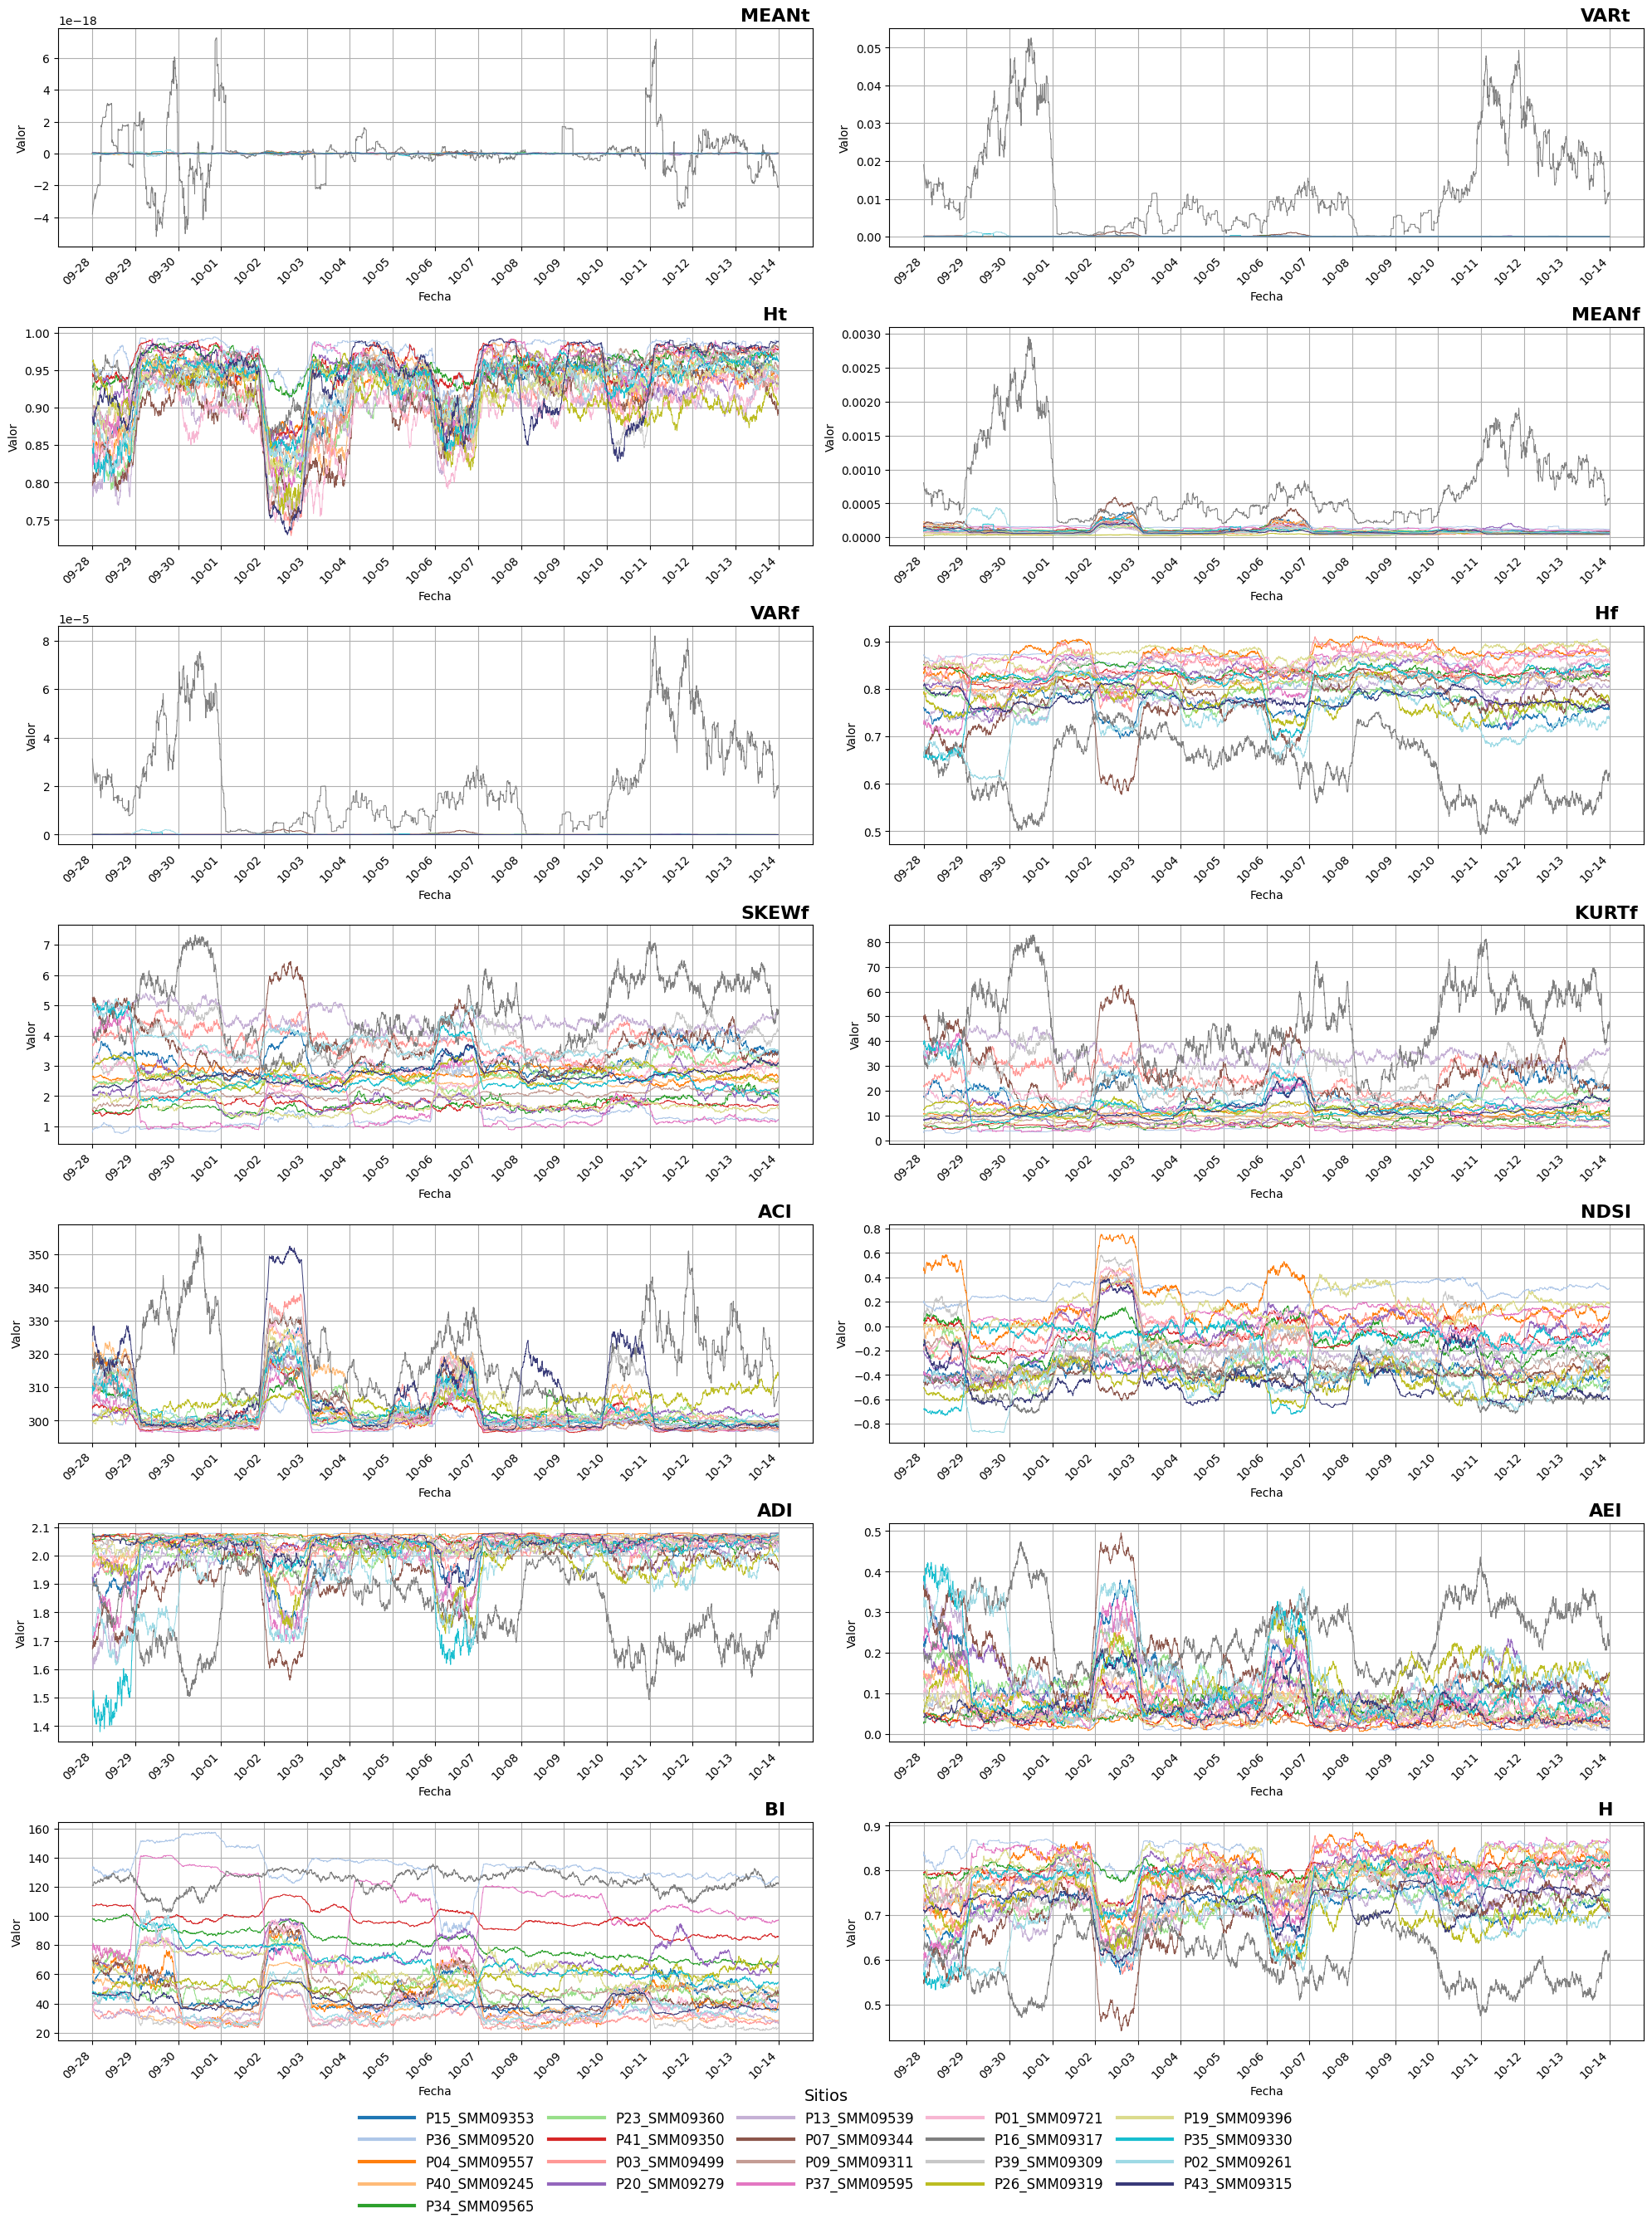

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

indices = ['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'H']
window_size = 72

# Suponiendo que df está definido antes y tiene las columnas 'datetime', 'site' y las de indices
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime'])

sites = df['site'].unique()

# Paleta combinada para muchos colores
colors_tab20 = plt.get_cmap('tab20').colors
colors_tab20b = plt.get_cmap('tab20b').colors
combined_colors = colors_tab20 + colors_tab20b

n_cols = 2
n_rows = int(np.ceil(len(indices) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))


axes = axes.flatten()

for i, idx in enumerate(indices):
    ax = axes[i]
    for j, site in enumerate(sites):
        grupo = df[df['site'] == site].sort_values('datetime')
        smoothed = grupo[idx].rolling(window=window_size, min_periods=1, center=True).mean()
        ax.plot(grupo['datetime'], smoothed, label=site if i == 0 else "", color=combined_colors[j % len(combined_colors)], linewidth=0.7)
    ax.set_title(idx, fontsize=16, fontweight='bold')
    ax.title.set_position((0.95, 1.05))  # mover título hacia arriba
    ax.set_ylabel('Valor')
    ax.grid(True)

# Configurar etiquetas eje x con mes y día para todos los subplots
for ax in axes:
    ax.set_xlabel('Fecha')
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Ajustar layout y espacio para leyenda abajo
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  # ajustar espacio inferior para leyenda

# Leyenda única centrada abajo, sin marco, 4 columnas, tamaño legible
leg = fig.legend(handles, labels, title='Sitios', title_fontsize=14, loc='lower center',
                 bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=12,
                 frameon=False, columnspacing=1, handlelength=4)

for legobj in leg.legend_handles:
    legobj.set_linewidth(3.0)  # aumenta el grosor de la línea


plt.show()



## figura en ingles

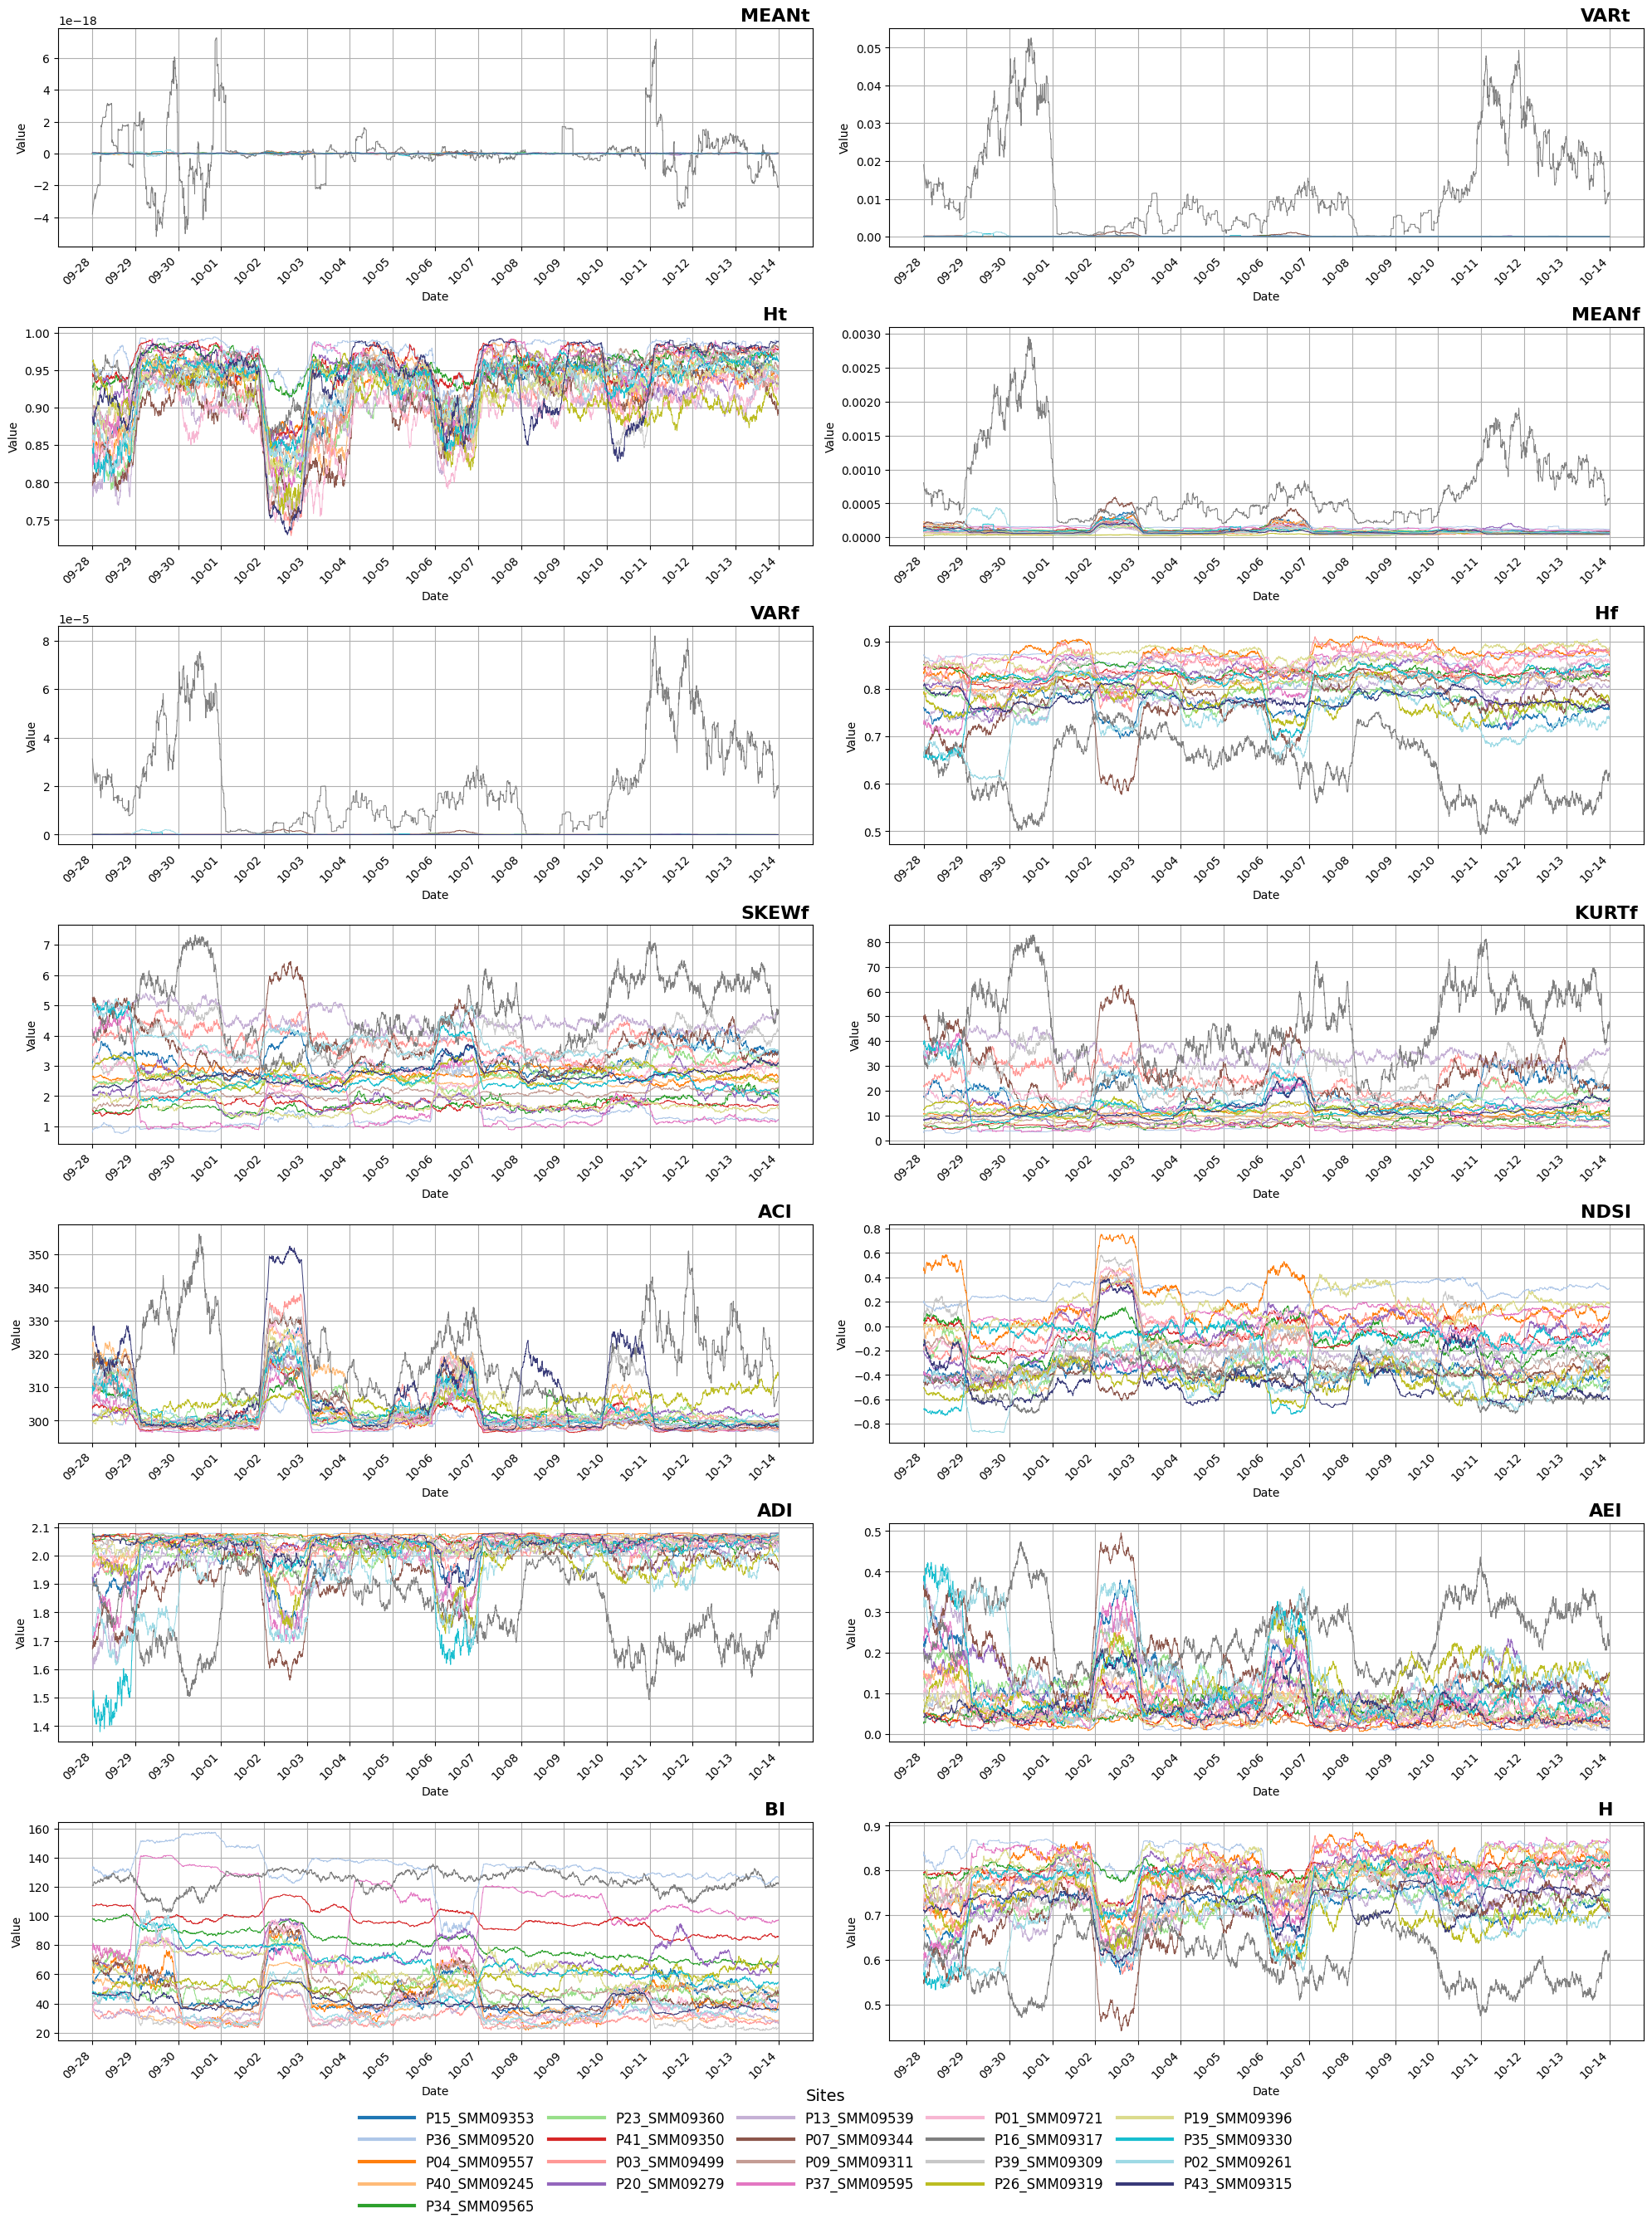

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

indices = ['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'H']
window_size = 72

# Suponiendo que df está definido antes y tiene las columnas 'datetime', 'site' y las de indices
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime'])

sites = df['site'].unique()

# Paleta combinada para muchos colores
colors_tab20 = plt.get_cmap('tab20').colors
colors_tab20b = plt.get_cmap('tab20b').colors
combined_colors = colors_tab20 + colors_tab20b

n_cols = 2
n_rows = int(np.ceil(len(indices) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))


axes = axes.flatten()

for i, idx in enumerate(indices):
    ax = axes[i]
    for j, site in enumerate(sites):
        grupo = df[df['site'] == site].sort_values('datetime')
        smoothed = grupo[idx].rolling(window=window_size, min_periods=1, center=True).mean()
        ax.plot(grupo['datetime'], smoothed, label=site if i == 0 else "", color=combined_colors[j % len(combined_colors)], linewidth=0.7)
    ax.set_title(idx, fontsize=16, fontweight='bold')
    ax.title.set_position((0.95, 1.05))  # mover título hacia arriba
    ax.set_ylabel('Value')
    ax.grid(True)

# Configurar etiquetas eje x con mes y día para todos los subplots
for ax in axes:
    ax.set_xlabel('Date')
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Ajustar layout y espacio para leyenda abajo
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  # ajustar espacio inferior para leyenda

# Leyenda única centrada abajo, sin marco, 4 columnas, tamaño legible
leg = fig.legend(handles, labels, title='Sites', title_fontsize=14, loc='lower center',
                 bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=12,
                 frameon=False, columnspacing=1, handlelength=4)

for legobj in leg.legend_handles:
    legobj.set_linewidth(3.0)  # aumenta el grosor de la línea


plt.show()



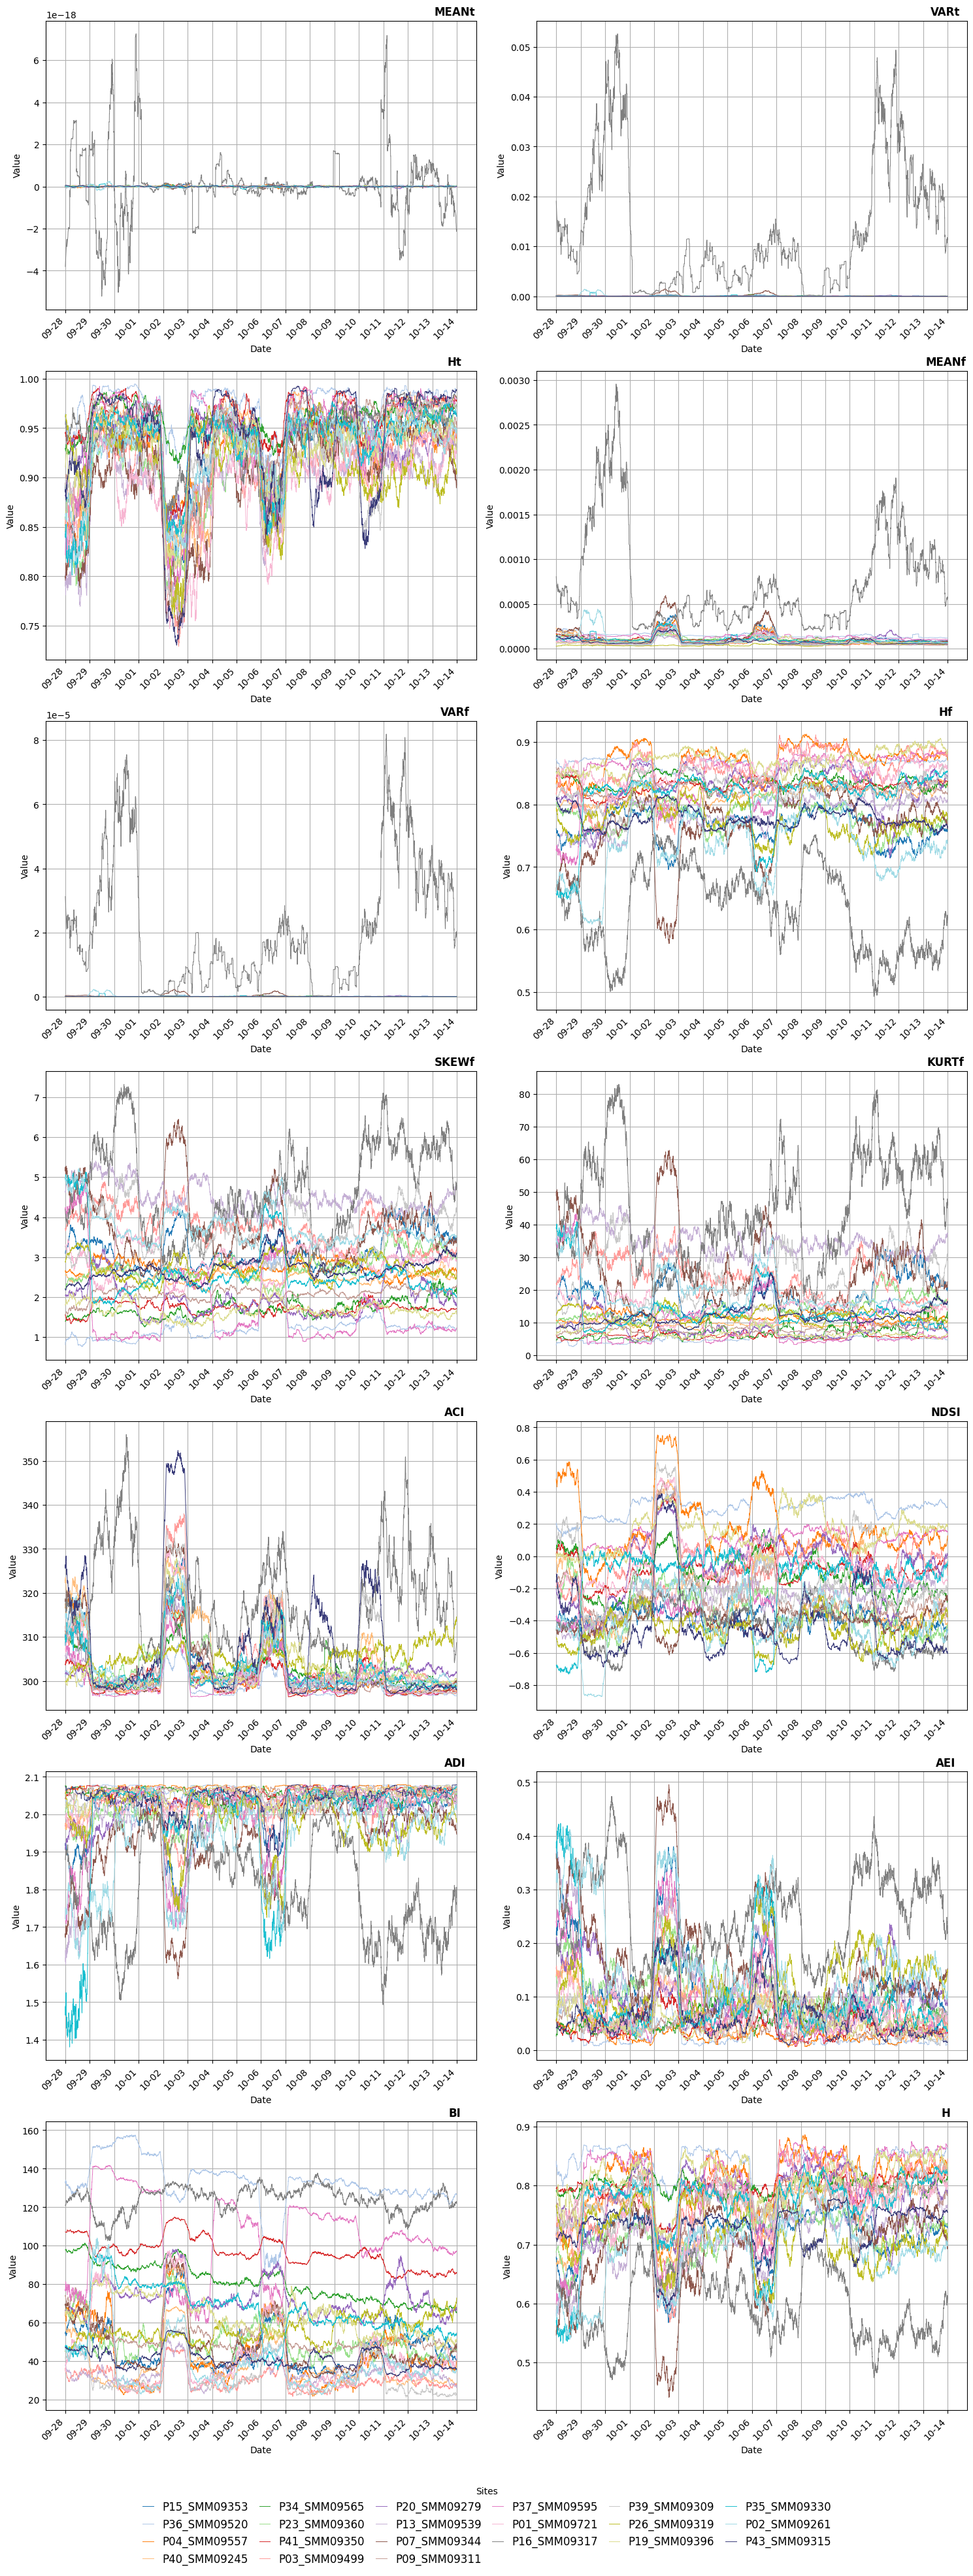

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

indices = ['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'H']
window_size = 72

# Suponiendo que df está definido antes y tiene las columnas 'datetime', 'site' y las de indices
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime'])

sites = df['site'].unique()

# Paleta combinada para muchos colores
colors_tab20 = plt.get_cmap('tab20').colors
colors_tab20b = plt.get_cmap('tab20b').colors
combined_colors = colors_tab20 + colors_tab20b

n_cols = 2
n_rows = int(np.ceil(len(indices) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))

axes = axes.flatten()

for i, idx in enumerate(indices):
    ax = axes[i]
    for j, site in enumerate(sites):
        grupo = df[df['site'] == site].sort_values('datetime')
        smoothed = grupo[idx].rolling(window=window_size, min_periods=1, center=True).mean()
        ax.plot(grupo['datetime'], smoothed, label=site if i == 0 else "", color=combined_colors[j % len(combined_colors)], linewidth=0.7)
    ax.set_title(idx, fontweight='bold')
    ax.title.set_position((0.95, 1.05))  # mover título hacia arriba
    ax.set_ylabel('Value')
    ax.grid(True)

# Configurar etiquetas eje x con mes y día para todos los subplots
for ax in axes:
    ax.set_xlabel('Date')
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Ajustar layout y espacio para leyenda abajo
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  # ajustar espacio inferior para leyenda

# Leyenda única centrada abajo, sin marco, 4 columnas, tamaño legible
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Sites', loc='lower center',
           bbox_to_anchor=(0.5, 0.06), ncol=6, fontsize=12,
           frameon=False, columnspacing=1, handlelength=1)

plt.show()
